# LSTM Rainfall-Runoff Prediction — CAMELS-US Benchmark

A proof-of-concept data-driven hydrological model that predicts daily streamflow from meteorological forcing using an LSTM neural network.

**Context:** This project is a mini-project of data-driven modeling with the LSTM approach for Rainfall-Runoff simulation using the CAMELS-US data based on the Kratzert, F. et al. (2018) Rainfall–runoff modelling using Long Short-Term Memory (LSTM) networks work.


**Data:** CAMELS-US dataset (Addor et al., 2017) with Daymet forcing — the community standard benchmark for data-driven hydrology (Kratzert et al., 2018, 2019).

**Reference:** Kratzert, F. et al. (2018) Rainfall–runoff modelling using Long Short-Term Memory (LSTM) networks *HESS*, (2019) Toward Improved Predictions in Ungauged Basins: Exploiting the Power of Machine Learning. *Water Resources Research*, 55(12).

## 0. Setup & Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import glob
import geopandas as gpd
import matplotlib.patches as mpatches

# For MacOS Apple silicon
print(f"PyTorch version: {torch.__version__}")
print(f"MPS available: {torch.backends.mps.is_available()}")  # M1 GPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# For windows
# print(f"PyTorch version: {torch.__version__}")
# print(f"CUDA available: {torch.cuda.is_available()}")
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Using device: {device}")


PyTorch version: 2.9.1
MPS available: True
Using device: mps


## 1. Configuration

Adjust `PROJECT_ROOT` to point to the directory containing your CAMELS data.

**Why Daymet?** Three forcing products are available in CAMELS-US (Daymet, NLDAS, Maurer). Daymet is the community standard used by Kratzert et al. (2019) and the NeuralHydrology framework, making results directly comparable to published benchmarks.

**5 variables?** We include 5 Daymet variables (prcp, tmax, tmin, srad, vp)
- `swe` (snow water equivalent) is excluded due to known reliability issues in the Daymet dataset,
  where the single-year estimation algorithm produces near-zero values for many basins
- `dayl` (day length) is excluded as it is largely redundant with `srad`,
  which already encodes seasonal daylight information, following Kratzert et al. (2018)

In [3]:
# --- Path setup ---
PROJECT_ROOT = "/Users/hans/Documents/LSTM"  # <-- Adjust this

TIMESERIES_DIR = os.path.join(
    PROJECT_ROOT,
    "basin_timeseries_v1p2_metForcing_obsFlow",
    "basin_dataset_public_v1p2"
)
ATTRIBUTES_DIR = os.path.join(PROJECT_ROOT, "camels_attributes_v2.0")

# --- Basin & period ---
# BASIN_ID = "01013500"  # Fish River, Maine (snow-dominated)
BASIN_ID = "13340600"  # NF CLEARWATER RIVER NR CANYON RANGER STATION ID

TRAIN_START = "1980-10-01"  # Water year splits
TRAIN_END   = "2000-09-30"  # ~20 water years
TEST_START  = "2000-10-01"
TEST_END    = "2010-09-30"  # ~10 water years

# --- Model hyperparameters ---
SEQ_LENGTH    = 365
HIDDEN_SIZE   = 64
NUM_LAYERS    = 1
DROPOUT       = 0.2
LEARNING_RATE = 0.001
EPOCHS        = 50   # ceiling — Early Stopping will terminate before this
BATCH_SIZE    = 256

# --- Early Stopping & scheduler ---
ES_PATIENCE   = 15    # stop if val_loss doesn't improve for 15 epochs
LR_PATIENCE   = 8     # halve LR if val_loss doesn't improve for 8 epochs
LR_FACTOR     = 0.5
WEIGHT_DECAY  = 1e-4

# --- 5 Daymet features ---
FEATURE_COLS = ["prcp", "srad", "tmax", "tmin", "vp"]

print("Configuration set.")
print(f"  Basin: {BASIN_ID}")
print(f"  Train: {TRAIN_START} -> {TRAIN_END}")
print(f"  Test:  {TEST_START} -> {TEST_END}")
print(f"  Features: {FEATURE_COLS}")
print(f"  Max epochs: {EPOCHS}  |  ES patience: {ES_PATIENCE}  |  LR patience: {LR_PATIENCE}")

Configuration set.
  Basin: 13340600
  Train: 1980-10-01 -> 2000-09-30
  Test:  2000-10-01 -> 2010-09-30
  Features: ['prcp', 'srad', 'tmax', 'tmin', 'vp']
  Max epochs: 50  |  ES patience: 15  |  LR patience: 8


## 1.1 Basin Location Map

Visualise all 671 CAMELS-US basins on a CONUS map. The **target basin** (set by `BASIN_ID`) is highlighted in red; all others are grey.

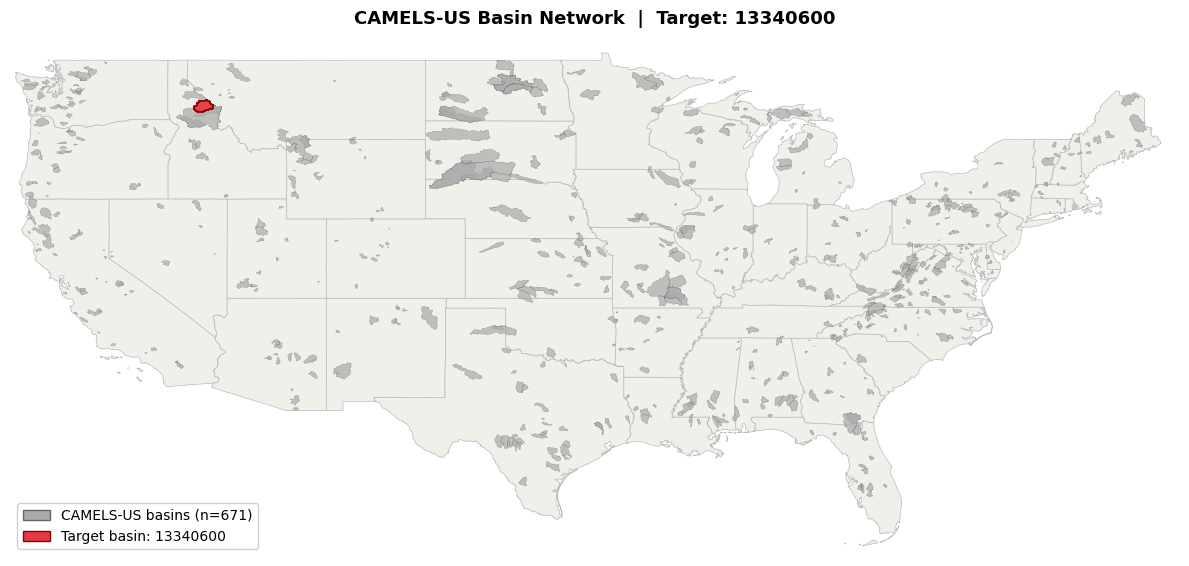

In [4]:
# --- Load data ---
SHAPEFILE   = os.path.join(PROJECT_ROOT, "basin_set_full_res", "HCDN_nhru_final_671.shp")
STATE_SHP   = os.path.join(PROJECT_ROOT, "cb_2018_us_state_5m","cb_2018_us_state_5m.shp")  # 다운받은 파일 경로

basins = gpd.read_file(SHAPEFILE)
states = gpd.read_file(STATE_SHP)

# US State shapefile
EXCLUDE = ["Alaska", "Hawaii", "Puerto Rico", "Guam",
           "United States Virgin Islands", "American Samoa",
           "Commonwealth of the Northern Mariana Islands"]
states = states[~states["NAME"].isin(EXCLUDE)]

target_hru_id = int(BASIN_ID)
is_target = basins["hru_id"] == target_hru_id

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 7), facecolor="white")

# State border
states.plot(ax=ax, facecolor="#f0f0eb", edgecolor="#bbbbbb", linewidth=0.5)

# Every basin 
basins[~is_target].plot(
    ax=ax, facecolor="#aaaaaa", edgecolor="#666666", linewidth=0.15, alpha=0.7
)

# Target basin (BASIN_ID)
basins[is_target].plot(
    ax=ax, facecolor="#e63946", edgecolor="#8b0000", linewidth=0.8, alpha=0.95
)

ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.set_aspect("equal")
ax.set_axis_off()

# Legend
grey_patch = mpatches.Patch(facecolor="#aaaaaa", edgecolor="#666666",
                             label=f"CAMELS-US basins (n={len(basins)})")
red_patch  = mpatches.Patch(facecolor="#e63946", edgecolor="#8b0000",
                             label=f"Target basin: {BASIN_ID}")
ax.legend(handles=[grey_patch, red_patch],
          loc="lower left", fontsize=10, framealpha=0.9, frameon=True)

ax.set_title(f"CAMELS-US Basin Network  |  Target: {BASIN_ID}",
             fontsize=13, fontweight="bold", pad=12)

plt.tight_layout()
plt.show()

## 2. Data Loading

CAMELS-US organizes basin files into HUC-2 region folders. We load:
1. **Forcing data** — 7 daily meteorological variables from Daymet
2. **Streamflow** — USGS observed daily discharge (cfs)
3. **Basin area** — from catchment attributes (needed for unit conversion)

In [5]:
def find_basin_file(base_dir, sub_dir, basin_id, suffix):
    pattern = os.path.join(base_dir, sub_dir, "*", f"{basin_id}{suffix}")
    matches = glob.glob(pattern)
    if not matches:
        raise FileNotFoundError(f"Basin file not found: {pattern}")
    return matches[0]


def load_forcing(timeseries_dir, basin_id):
    path = find_basin_file(
        timeseries_dir, "basin_mean_forcing/daymet",
        basin_id, "_lump_cida_forcing_leap.txt")
    df = pd.read_csv(path, sep=r'\s+', skiprows=4,
        names=["Year","Mnth","Day","Hr","dayl","prcp","srad","swe","tmax","tmin","vp"])
    df["date"] = pd.to_datetime(df[["Year","Mnth","Day"]].rename(
        columns={"Year":"year","Mnth":"month","Day":"day"}))
    return df.set_index("date")[FEATURE_COLS]

def load_streamflow(timeseries_dir, basin_id):
    path = find_basin_file(
        timeseries_dir, "usgs_streamflow",
        basin_id, "_streamflow_qc.txt")
    df = pd.read_csv(path, sep=r'\s+',
        names=["basin","Year","Mnth","Day","Q","QC_flag"])
    df["date"] = pd.to_datetime(df[["Year","Mnth","Day"]].rename(
        columns={"Year":"year","Mnth":"month","Day":"day"}))
    df.loc[(df["Q"] < 0) | (df["QC_flag"] == "M"), "Q"] = np.nan
    return df.set_index("date")[["Q"]]

def load_basin_area(basin_id):
    """Load basin area (km2) from CAMELS attributes (.txt)."""
    topo_txt = os.path.join(ATTRIBUTES_DIR, "camels_topo.txt")
    if not os.path.exists(topo_txt):
        raise FileNotFoundError(
            f"Cannot find basin attributes: {topo_txt}\n"
            f"Check that ATTRIBUTES_DIR is correct."
        )
    attrs = pd.read_csv(topo_txt, sep=';')
    attrs['gauge_id'] = attrs['gauge_id'].astype(str).str.zfill(8)
    row = attrs.loc[attrs['gauge_id'] == basin_id]
    if len(row) == 0:
        raise ValueError(f"Basin {basin_id} not found in {topo_txt}")
    return row['area_gages2'].values[0]

def load_basin_lat(basin_id):
    """Load basin centroid latitude from CAMELS attributes."""
    topo_txt = os.path.join(ATTRIBUTES_DIR, "camels_topo.txt")
    attrs = pd.read_csv(topo_txt, sep=';')
    attrs['gauge_id'] = attrs['gauge_id'].astype(str).str.zfill(8)
    row = attrs.loc[attrs['gauge_id'] == basin_id]
    if len(row) == 0:
        raise ValueError(f"Basin {basin_id} not found in {topo_txt}")
    return float(row['gauge_lat'].values[0])

In [6]:
# --- Execute data loading ---
forcing    = load_forcing(TIMESERIES_DIR, BASIN_ID)
streamflow = load_streamflow(TIMESERIES_DIR, BASIN_ID)
basin_area = load_basin_area(BASIN_ID)

print(f"Basin area     : {basin_area:.1f} km^2")
print(f"Forcing period : {forcing.index[0].date()} to {forcing.index[-1].date()}")
print(f"Forcing vars   : {list(forcing.columns)}")
print(f"Streamflow     : {streamflow.index[0].date()} to {streamflow.index[-1].date()}")
print()
forcing.head()

Basin area     : 3354.6 km^2
Forcing period : 1980-01-01 to 2014-12-31
Forcing vars   : ['prcp', 'srad', 'tmax', 'tmin', 'vp']
Streamflow     : 1980-01-01 to 2014-12-31



,prcp,srad,tmax,tmin,vp
date,,,,,
1980-01-01,7.76,60.00,1.00,-4.22,448.63
1980-01-02,7.57,76.67,2.13,-4.21,450.17
1980-01-03,6.02,93.75,1.46,-6.78,369.63
1980-01-04,0.00,174.28,-1.94,-14.86,201.13
1980-01-05,20.24,120.59,-0.42,-11.16,263.56


### 2.1 Quick Data Exploration

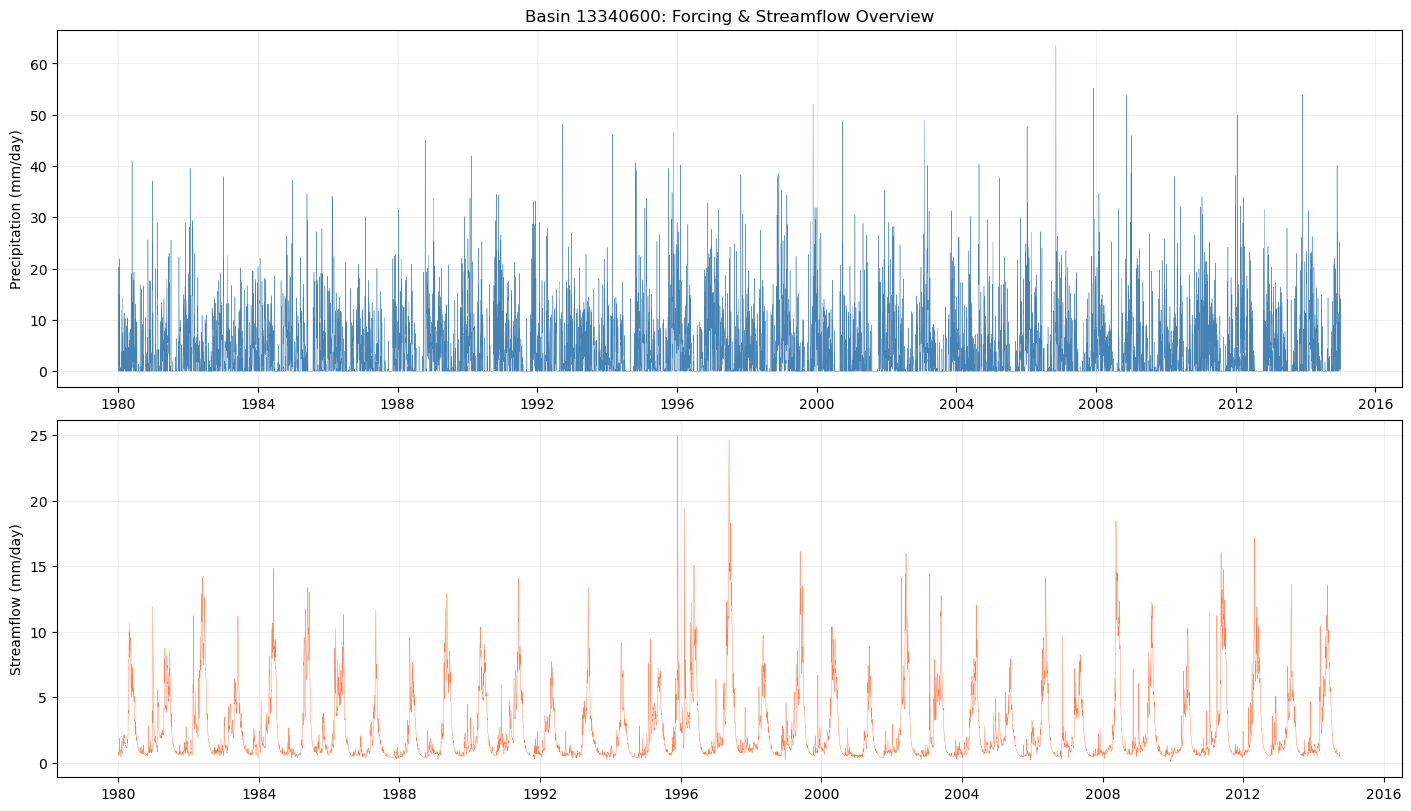

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), constrained_layout=True)

axes[0].plot(forcing.index, forcing["prcp"], lw=0.3, color="steelblue")
axes[0].set_ylabel("Precipitation (mm/day)")
axes[0].set_title(f"Basin {BASIN_ID}: Forcing & Streamflow Overview")
axes[0].grid(True, alpha=0.2)


cfs_to_mm = 0.0283168 * 86400 / (basin_area * 1e6) * 1000
sf_plot = streamflow.copy()
sf_plot["Q_mm"] = sf_plot["Q"] * cfs_to_mm
axes[1].plot(sf_plot.index, sf_plot["Q_mm"], lw=0.3, color="coral")
axes[1].set_ylabel("Streamflow (mm/day)")
axes[1].grid(True, alpha=0.2)

plt.show()

## 3. Preprocessing

Key steps:
1. **Unit conversion**: Streamflow from cfs to mm/day using basin area
2. **Join** forcing + streamflow on date, drop NaN rows
3. **Train/val/test split** by water year — split at the **date level** before sequence creation
4. **Standardization**: Fit scalers on `train_raw` only — no leakage from val or test
5. **Sliding window**: `create_sequences()` called separately per split — no boundary overlap between train and val

In [8]:
def create_sequences(features, target, seq_len):
    X, y = [], []
    for i in range(len(features) - seq_len):
        X.append(features[i : i + seq_len])
        y.append(target[i + seq_len])
    return np.array(X), np.array(y)

In [9]:
def prepare_data(forcing, streamflow, basin_area,
                 train_start, train_end, test_start, test_end,
                 seq_length, val_fraction=0.2):
    cfs_to_mm = 0.0283168 * 86400 / (basin_area * 1e6) * 1000
    streamflow_c = streamflow.copy()
    streamflow_c["Q"] = streamflow_c["Q"] * cfs_to_mm
    data = forcing.join(streamflow_c, how="inner").dropna()
    feature_cols = list(forcing.columns)

    train_data = data[train_start:train_end]
    test_data  = data[test_start:test_end]

    # Split at date level before creating sequences — prevents 365-day window overlap
    val_cutoff = int(len(train_data) * (1 - val_fraction))
    train_raw  = train_data.iloc[:val_cutoff]
    val_raw    = train_data.iloc[val_cutoff:]

    # Fit scalers on train_raw only
    feature_scaler = StandardScaler()
    target_scaler  = StandardScaler()
    train_X = feature_scaler.fit_transform(train_raw[feature_cols])
    train_y = target_scaler.fit_transform(train_raw[["Q"]])
    val_X   = feature_scaler.transform(val_raw[feature_cols])
    val_y   = target_scaler.transform(val_raw[["Q"]])
    test_X  = feature_scaler.transform(test_data[feature_cols])
    test_y  = target_scaler.transform(test_data[["Q"]])

    X_train, y_train = create_sequences(train_X, train_y, seq_length)
    X_val,   y_val   = create_sequences(val_X,   val_y,   seq_length)
    X_test,  y_test  = create_sequences(test_X,  test_y,  seq_length)
    test_dates = test_data.index[seq_length:]

    print(f"  Train : {len(train_raw)} days  →  {len(X_train)} sequences")
    print(f"  Val   : {len(val_raw)} days  →  {len(X_val)} sequences")
    print(f"  Test  :                   {len(X_test)} sequences")
    print(f"  Input shape : {X_train.shape}")
    return (X_train, y_train, X_val, y_val, X_test, y_test,
            feature_scaler, target_scaler, test_dates)


(X_train, y_train, X_val, y_val, X_test, y_test,
 feature_scaler, target_scaler, test_dates) = prepare_data(
    forcing, streamflow, basin_area,
    TRAIN_START, TRAIN_END, TEST_START, TEST_END, SEQ_LENGTH)

  Train : 5844 days  →  5479 sequences
  Val   : 1461 days  →  1096 sequences
  Test  :                   3287 sequences
  Input shape : (5479, 365, 5)


## 4. Model Definition

The LSTM processes the 365-day meteorological sequence step by step, building an internal hidden state that implicitly encodes antecedent soil moisture, snowpack evolution, and seasonal patterns. The final hidden state is mapped through a fully-connected layer to predict streamflow.

```
Input: (batch=256, seq=365, features=5)
  ↓
LSTM(hidden=64, layers=1)
  ↓
Dropout(0.2)
  ↓
FC Layer(64 → 1)
  ↓
Output: Q̂ (mm/day)
```

In [10]:
class CatchmentDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

class LSTMRainfallRunoff(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_step = lstm_out[:, -1, :]
        return self.fc(self.dropout(last_step))

torch.manual_seed(42)
np.random.seed(42)

n_features = X_train.shape[2]
model = LSTMRainfallRunoff(n_features, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model: LSTM(in={n_features}, hidden={HIDDEN_SIZE}) -> FC -> 1")
print(f"Parameters: {n_params:,}")
print(f"Device: {device}")

Model: LSTM(in=5, hidden=64) -> FC -> 1
Parameters: 18,241
Device: mps


## 5. Training

Three overfitting countermeasures applied together:

- **Weight Decay** (`1e-4`): L2 penalty on weights — discourages the model from memorizing training-period patterns
- **ReduceLROnPlateau**: halves the learning rate when val_loss stops improving for `LR_PATIENCE` epochs — lets the model fine-tune rather than overshoot
- **Early Stopping**: halts training when val_loss shows no improvement for `ES_PATIENCE` epochs — `EPOCHS` is just a ceiling, not a target

`optimizer` and `scheduler` are created outside `train_model` and passed in, keeping the function reusable.

In [11]:
def train_model(model, train_loader, X_val, y_val, optimizer, scheduler,
                epochs, device, patience=15):
    criterion = nn.MSELoss()
    val_X_t = torch.FloatTensor(X_val).to(device)
    val_y_t = torch.FloatTensor(y_val).to(device)
    train_losses, val_losses = [], []

    best_val_loss    = float("inf")
    best_epoch       = 0
    best_state       = None
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for bX, by in train_loader:
            bX, by = bX.to(device), by.to(device)
            pred = model(bX)
            loss = criterion(pred, by)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        avg_train = epoch_loss / len(train_loader)
        train_losses.append(avg_train)

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(val_X_t), val_y_t).item()
        val_losses.append(val_loss)

        if scheduler is not None:
            scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_epoch       = epoch + 1
            best_state       = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 10 == 0 or epoch == 0:
            marker = " ←best" if patience_counter == 0 else f"  (patience {patience_counter}/{patience})"
            print(f"  Epoch {epoch+1:3d}/{epochs} | Train: {avg_train:.6f} | Val: {val_loss:.6f}{marker}")

        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch + 1}  (no improvement for {patience} epochs)")
            break

    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    print(f"  Best epoch: {best_epoch}  (val_loss={best_val_loss:.6f})")
    return train_losses, val_losses


train_loader = DataLoader(CatchmentDataset(X_train, y_train),
                          batch_size=BATCH_SIZE, shuffle=True)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=LR_PATIENCE, factor=LR_FACTOR
)

print(f"Training (max {EPOCHS} epochs, early stopping patience={ES_PATIENCE})...")
train_losses, val_losses = train_model(
    model, train_loader, X_val, y_val, optimizer, scheduler,
    EPOCHS, device, patience=ES_PATIENCE)
print("Training complete.")

Training (max 50 epochs, early stopping patience=15)...
  Epoch   1/50 | Train: 0.935643 | Val: 0.829371 ←best
  Epoch  10/50 | Train: 0.110611 | Val: 0.175063 ←best
  Epoch  20/50 | Train: 0.063372 | Val: 0.255907  (patience 10/15)
  Early stopping at epoch 25  (no improvement for 15 epochs)
  Best epoch: 10  (val_loss=0.175063)
Training complete.


## 6. Baseline Comparison

We compare the LSTM against two baselines:

1. **Linear regression** (Section 6 below) — naive feature-to-flow mapping using only the most recent day. This is the *floor* baseline.
2. **GR4J** (Section 6.1) — a 4-parameter physical-based conceptual model (Perrin et al., 2003) calibrated on the training period. This is the *meaningful* baseline that any data-driven model should beat to justify its complexity.

In [12]:
def train_linear_baseline(X_train, y_train, X_test, y_test):
    X_tr = X_train[:, -1, :]
    X_te = X_test[:, -1, :]
    reg = LinearRegression().fit(X_tr, y_train.ravel())
    return reg.predict(X_te)

pred_base_scaled = train_linear_baseline(X_train, y_train, X_test, y_test)
print("Baseline model trained.")

Baseline model trained.


### 6.1 GR4J + Snow: Physical-based Baseline

**GR4J** (Perrin et al., 2003) is a 4-parameter lumped conceptual rainfall-runoff
model. It serves as a stronger physical-based baseline than linear regression and
provides a direct *data-driven vs. process-based* comparison for the LSTM.

**Snow extension.** Pure GR4J treats every mm of precipitation as instant rainfall.
For snow-influenced basins this is fatal: winter snowfall produces phantom runoff
and the spring snowmelt peak is missed, regardless of how the four GR4J parameters
are tuned. We therefore add a 3-parameter **degree-day temperature-index snow module**
in front of GR4J:

- `t_snow` — phase threshold (°C). Below it, precipitation accumulates as snow.
- `t_melt` — melt onset threshold (°C). Above it, the snowpack melts.
- `ddf`    — degree-day melt factor (mm/°C/day).

The snow module converts (`prcp`, `tavg`) into *effective rainfall* (rain + meltwater)
which is then fed to the GR4J production store. All seven parameters are calibrated
jointly on the training period via `scipy.optimize.differential_evolution`. The GR4J
core bounds (X1..X4) follow Perrin et al. (2003) ranges with a safety margin —
earlier narrower bounds caused X1 and X3 to saturate at the upper edge for
snow-dominated PNW basins (e.g. 13340600), so widening lets the calibrator find a
physically realistic deeper storage. Snow parameter bounds are kept moderate so
the snow module remains identifiable rather than absorbing GR4J routing dynamics.

**Note:** GR4J needs PET, which the Daymet forcing does not provide directly. We
compute PET on-the-fly using the **Hargreaves equation** from `tmin`, `tmax`, and
basin latitude. Daily mean temperature for the snow module is taken as
`tavg = (tmin + tmax) / 2`.

In [13]:
# ── 6.1-A.  Prepare GR4J inputs (raw P, T, PET, Q — no scaling) ───────────────
# GR4J is a physical-based model, so we use raw mm/day units (no scaling),
# but we use the SAME train/test split and SAME basin as the LSTM for
# a fair comparison.

from gr4j import (simulate_gr4j_snow, hargreaves_pet, calibrate_gr4j_snow,
                  DEFAULT_BOUNDS_SNOW)

# --- Get basin latitude from CAMELS attributes (for Hargreaves PET) ---
BASIN_LAT = load_basin_lat(BASIN_ID)
print(f"Basin gauge latitude: {BASIN_LAT:.3f} °N")

# --- Build raw forcing+flow DataFrame (same merge logic as prepare_data) ---
cfs_to_mm = 0.0283168 * 86400 / (basin_area * 1e6) * 1000
streamflow_mm = streamflow.copy()
streamflow_mm["Q"] = streamflow_mm["Q"] * cfs_to_mm
gr4j_data = forcing.join(streamflow_mm, how="inner").dropna()

# --- Compute PET via Hargreaves ---
gr4j_data["pet"] = hargreaves_pet(
    tmin_c=gr4j_data["tmin"].values,
    tmax_c=gr4j_data["tmax"].values,
    lat_deg=BASIN_LAT,
    dates=gr4j_data.index,
)

# --- Daily mean temperature for the degree-day snow module ---
gr4j_data["tavg"] = 0.5 * (gr4j_data["tmin"] + gr4j_data["tmax"])

# --- Train / Test split (same dates as LSTM) ---
gr4j_train = gr4j_data[TRAIN_START:TRAIN_END]
gr4j_test  = gr4j_data[TEST_START:TEST_END]

print(f"\nGR4J data prepared:")
print(f"  Train period : {gr4j_train.index[0].date()} → {gr4j_train.index[-1].date()}  ({len(gr4j_train)} days)")
print(f"  Test  period : {gr4j_test.index[0].date()}  → {gr4j_test.index[-1].date()}   ({len(gr4j_test)} days)")
print(f"\nClimatology check:")
print(f"  Mean P     : {gr4j_data['prcp'].mean():.2f} mm/day  ({gr4j_data['prcp'].sum()/len(gr4j_data)*365:.0f} mm/yr)")
print(f"  Mean PET   : {gr4j_data['pet'].mean():.2f} mm/day  ({gr4j_data['pet'].sum()/len(gr4j_data)*365:.0f} mm/yr)")
print(f"  Mean Tavg  : {gr4j_data['tavg'].mean():.2f} °C     "
      f"(min={gr4j_data['tavg'].min():.1f}, max={gr4j_data['tavg'].max():.1f})")
print(f"  Mean Q     : {gr4j_data['Q'].mean():.2f} mm/day   ({gr4j_data['Q'].sum()/len(gr4j_data)*365:.0f} mm/yr)")
print(f"  Runoff coef: {gr4j_data['Q'].mean()/gr4j_data['prcp'].mean():.3f}")

Basin gauge latitude: 46.840 °N

GR4J data prepared:
  Train period : 1980-10-01 → 2000-09-30  (7305 days)
  Test  period : 2000-10-01  → 2010-09-30   (3652 days)

Climatology check:
  Mean P     : 3.73 mm/day  (1361 mm/yr)
  Mean PET   : 2.28 mm/day  (834 mm/yr)
  Mean Tavg  : 5.20 °C     (min=-28.9, max=24.7)
  Mean Q     : 2.45 mm/day   (894 mm/yr)
  Runoff coef: 0.657


In [14]:
# ── 6.1-B.  Calibrate GR4J + degree-day snow on the training period ──────────
# Optimises 7 parameters jointly:
#     [X1, X2, X3, X4, t_snow, t_melt, ddf]
# by maximising NSE. The first 365 days are warm-up (excluded from the
# objective), matching the LSTM SEQ_LENGTH so both models start evaluation
# from the same point.

WARMUP_DAYS = 365   # spin-up — matches LSTM SEQ_LENGTH for fair comparison

print("Calibrating GR4J + snow on the training period (this takes minutes)...")
gr4j_cal = calibrate_gr4j_snow(
    P     = gr4j_train["prcp"].values,
    T     = gr4j_train["tavg"].values,
    E     = gr4j_train["pet"].values,
    Q_obs = gr4j_train["Q"].values,
    warmup  = WARMUP_DAYS,
    maxiter = 200,
    seed    = 42,
    workers = 1,        # set to -1 for parallel (faster but non-deterministic)
    verbose = True,
)

GR4J_PARAMS = gr4j_cal["params"]

Calibrating GR4J + snow on the training period (this takes minutes)...
  Calibration OK (iters=95, NSE_train=0.7748)
    X1     =   889.66  (production capacity, mm)
    X2     =    5.371  (exchange coefficient, mm/day)
    X3     =   402.39  (routing capacity, mm)
    X4     =    1.250  (UH time base, days)
    t_snow =   -1.856  (phase threshold, degC)
    t_melt =    2.195  (melt onset, degC)
    ddf    =    2.467  (degree-day factor, mm/degC/day)


In [15]:
# ── 6.1-C.  Simulate on the full period, then evaluate train & test ──────────
# We run GR4J + snow on the full series (train + test) so the production,
# routing, and SWE stores at the start of the test period reflect realistic
# antecedent conditions rather than a cold reset.

# Full period covering train and test
gr4j_full = gr4j_data.loc[TRAIN_START:TEST_END]

Q_gr4j_full = simulate_gr4j_snow(
    P      = gr4j_full["prcp"].values,
    T      = gr4j_full["tavg"].values,
    E      = gr4j_full["pet"].values,
    params = GR4J_PARAMS,
)

# Slice back into train / test using the same indices
gr4j_full = gr4j_full.assign(Q_sim=Q_gr4j_full)
pred_gr4j_train = gr4j_full.loc[TRAIN_START:TRAIN_END, "Q_sim"].values
pred_gr4j_test  = gr4j_full.loc[TEST_START:TEST_END,  "Q_sim"].values

# Drop warmup days from train evaluation
pred_gr4j_train_eval = pred_gr4j_train[WARMUP_DAYS:]
obs_gr4j_train_eval  = gr4j_train["Q"].values[WARMUP_DAYS:]

# Test predictions aligned to LSTM test_dates (LSTM drops the first SEQ_LENGTH
# of the test set, so we align GR4J the same way for matched evaluation)
gr4j_test_with_sim = gr4j_full.loc[TEST_START:TEST_END]
pred_gr4j_test_aligned = gr4j_test_with_sim["Q_sim"].values[SEQ_LENGTH:]
obs_gr4j_test_aligned  = gr4j_test_with_sim["Q"].values[SEQ_LENGTH:]

print(f"GR4J + snow simulation complete.")
print(f"  Train (post-warmup) : {len(pred_gr4j_train_eval)} days")
print(f"  Test  (LSTM-aligned): {len(pred_gr4j_test_aligned)} days")

GR4J + snow simulation complete.
  Train (post-warmup) : 6940 days
  Test  (LSTM-aligned): 3287 days


## 7. Evaluation

| Metric | Meaning | Good threshold |
|--------|---------|----------------|
| **NSE** | Nash-Sutcliffe Efficiency (1 = perfect) | > 0.70 |
| **KGE** | Kling-Gupta Efficiency | > 0.70 |
| **RMSE** | Root Mean Squared Error (mm/day) | lower is better |
| **PBIAS** | Percent Bias (+ = overestimation) | < ±10% |

In [16]:
def calc_nse(obs, pred):
    return 1 - np.sum((obs - pred)**2) / np.sum((obs - np.mean(obs))**2)

def calc_kge(obs, pred):
    r = np.corrcoef(obs.flatten(), pred.flatten())[0, 1]
    alpha = np.std(pred) / np.std(obs)
    beta = np.mean(pred) / np.mean(obs)
    return 1 - np.sqrt((r-1)**2 + (alpha-1)**2 + (beta-1)**2)

def calc_rmse(obs, pred):
    return np.sqrt(np.mean((obs - pred)**2))

def calc_pbias(obs, pred):
    return 100 * np.sum(pred - obs) / np.sum(obs)

def evaluate(obs, pred, label=""):
    m = {"NSE": calc_nse(obs, pred), "KGE": calc_kge(obs, pred),
         "RMSE": calc_rmse(obs, pred), "PBIAS": calc_pbias(obs, pred)}
    print(f"  {label}")
    for k, v in m.items():
        fmt = f"{v:.4f}" if k != "PBIAS" else f"{v:.2f}%"
        print(f"    {k:6s} = {fmt}")
    return m

# Generate predictions
model.eval()
with torch.no_grad():
    pred_scaled = model(torch.FloatTensor(X_test).to(device)).cpu().numpy()

pred_lstm = np.maximum(target_scaler.inverse_transform(pred_scaled).flatten(), 0)
obs       = target_scaler.inverse_transform(y_test).flatten()
pred_base = np.maximum(target_scaler.inverse_transform(pred_base_scaled.reshape(-1,1)).flatten(), 0)

# Sanity-check that LSTM obs and GR4J obs align (same dates, same values)
assert len(obs) == len(obs_gr4j_test_aligned), \
    f"Length mismatch: LSTM obs={len(obs)}, GR4J obs={len(obs_gr4j_test_aligned)}"
assert np.allclose(obs, obs_gr4j_test_aligned, atol=1e-6), \
    "LSTM and GR4J observed flows differ — check date alignment!"

print(f"Test Period: {TEST_START} to {TEST_END}")
print("=" * 50)
m_lstm = evaluate(obs, pred_lstm,                "LSTM")
print()
m_gr4j = evaluate(obs, pred_gr4j_test_aligned,   "GR4J (physical baseline)")
print()
m_base = evaluate(obs, pred_base,                "Linear regression (floor)")
print()
print(f"NSE improvement (LSTM over GR4J)   : {m_lstm['NSE'] - m_gr4j['NSE']:+.4f}")
print(f"NSE improvement (LSTM over Linear) : {m_lstm['NSE'] - m_base['NSE']:+.4f}")
print(f"NSE improvement (GR4J over Linear) : {m_gr4j['NSE'] - m_base['NSE']:+.4f}")
print("=" * 50)


Test Period: 2000-10-01 to 2010-09-30
  LSTM
    NSE    = 0.7725
    KGE    = 0.8695
    RMSE   = 1.2567
    PBIAS  = 4.55%

  GR4J (physical baseline)
    NSE    = 0.6394
    KGE    = 0.7310
    RMSE   = 1.5822
    PBIAS  = 0.86%

  Linear regression (floor)
    NSE    = 0.3900
    KGE    = 0.4344
    RMSE   = 2.0578
    PBIAS  = 2.83%

NSE improvement (LSTM over GR4J)   : +0.1331
NSE improvement (LSTM over Linear) : +0.3825
NSE improvement (GR4J over Linear) : +0.2494


## 8. Visualization

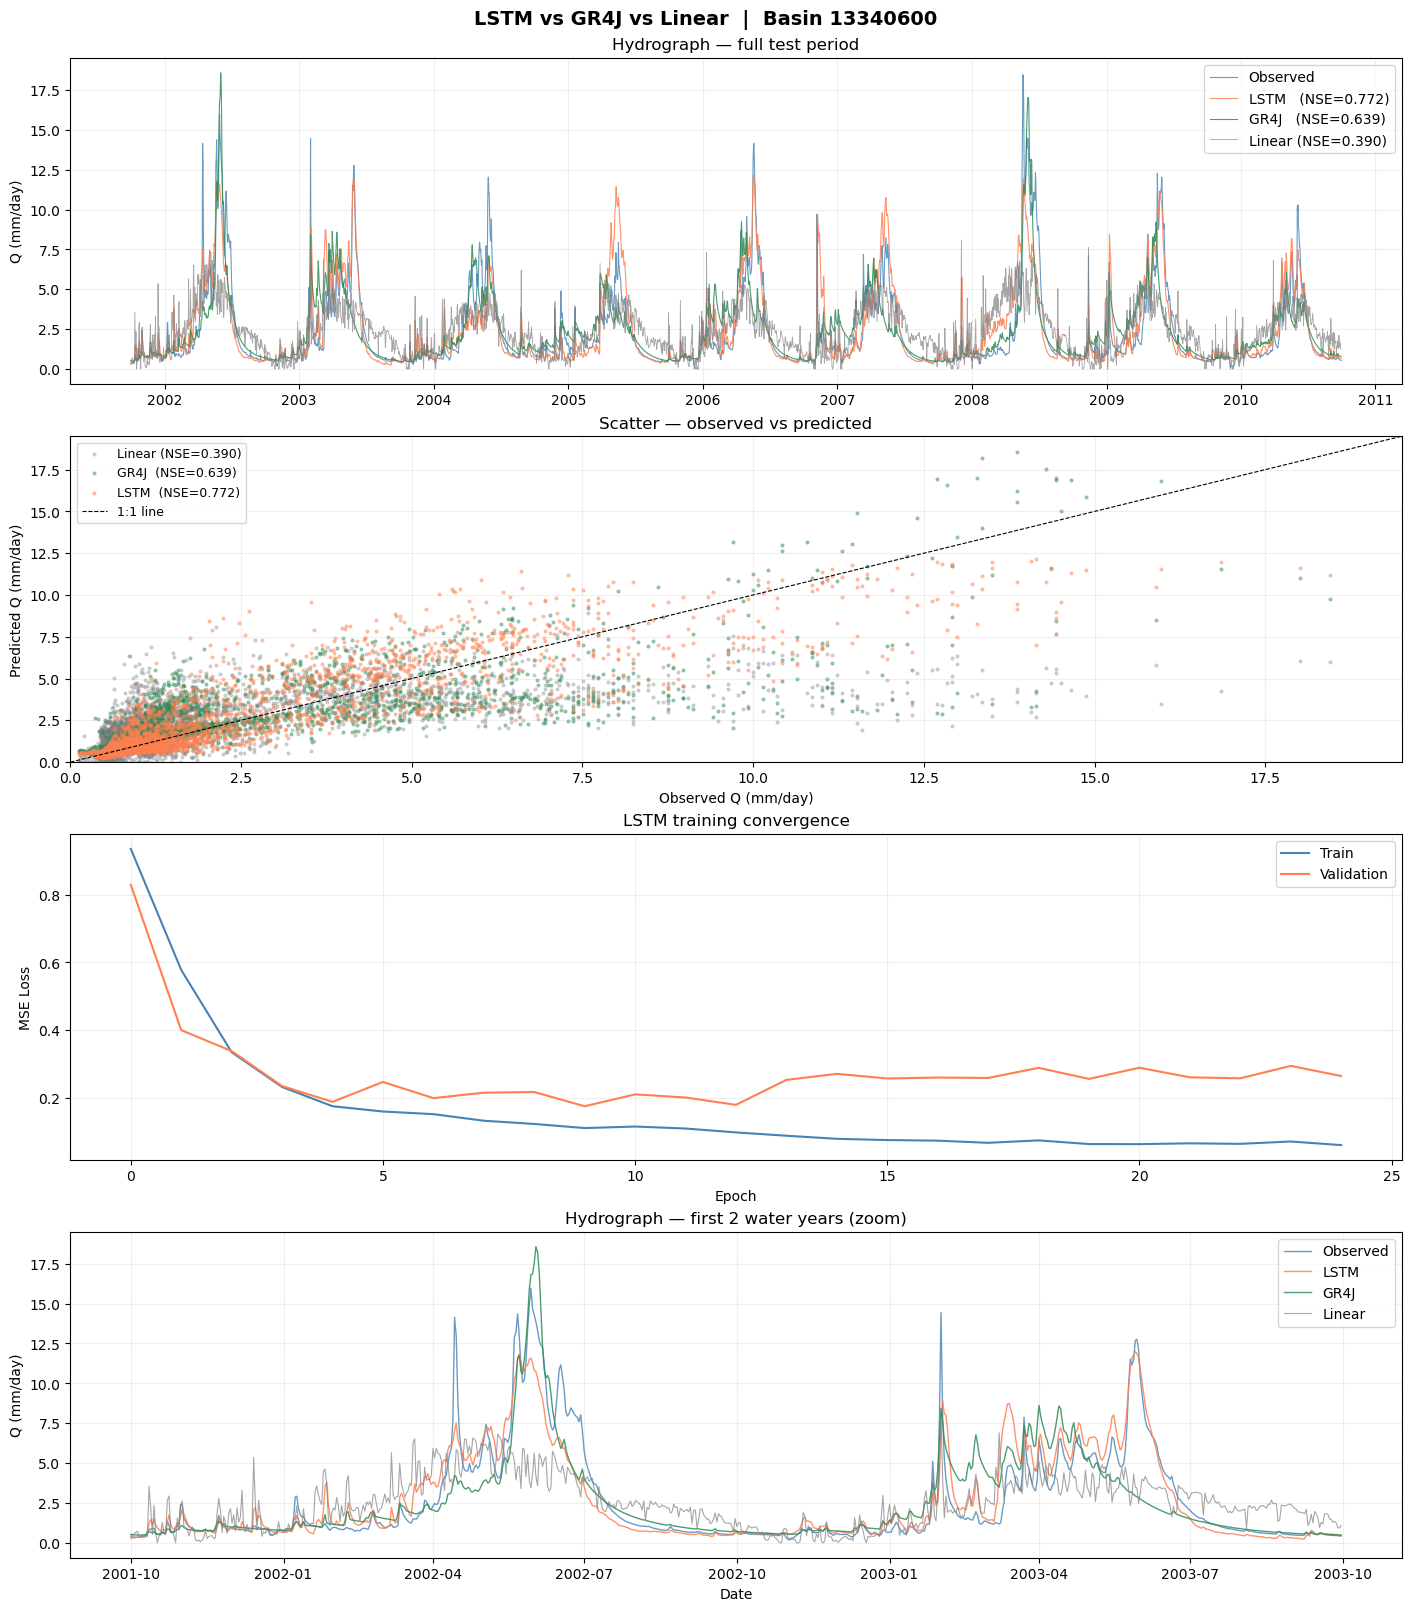

Figure saved: lstm_results_13340600.png


In [17]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16), constrained_layout=True)
fig.suptitle(f"LSTM vs GR4J vs Linear  |  Basin {BASIN_ID}", fontsize=14, fontweight="bold")

# --- Panel 1: full test hydrograph (obs vs LSTM vs GR4J vs Linear) ---
ax = axes[0]
ax.plot(test_dates, obs,                     "steelblue", lw=0.8, alpha=0.8,  label="Observed")
ax.plot(test_dates, pred_lstm,               "coral",     lw=0.8, alpha=0.85, label=f"LSTM   (NSE={m_lstm['NSE']:.3f})")
ax.plot(test_dates, pred_gr4j_test_aligned,  "seagreen",  lw=0.8, alpha=0.85, label=f"GR4J   (NSE={m_gr4j['NSE']:.3f})")
ax.plot(test_dates, pred_base,               "gray",      lw=0.6, alpha=0.7,  label=f"Linear (NSE={m_base['NSE']:.3f})")
ax.set_ylabel("Q (mm/day)")
ax.set_title("Hydrograph — full test period")
ax.legend(); ax.grid(True, alpha=0.2)

# --- Panel 2: scatter — observed vs predicted ---
ax = axes[1]
vmax = max(obs.max(), pred_lstm.max(), pred_gr4j_test_aligned.max(), pred_base.max()) * 1.05
ax.scatter(obs, pred_base,                   s=4, alpha=0.3, c="gray",     label=f"Linear (NSE={m_base['NSE']:.3f})")
ax.scatter(obs, pred_gr4j_test_aligned,      s=4, alpha=0.4, c="seagreen", label=f"GR4J  (NSE={m_gr4j['NSE']:.3f})")
ax.scatter(obs, pred_lstm,                   s=4, alpha=0.4, c="coral",    label=f"LSTM  (NSE={m_lstm['NSE']:.3f})")
ax.plot([0, vmax], [0, vmax], "k--", lw=0.8, label="1:1 line")
ax.set_xlabel("Observed Q (mm/day)"); ax.set_ylabel("Predicted Q (mm/day)")
ax.set_title("Scatter — observed vs predicted")
ax.legend(fontsize=9); ax.set_xlim(0, vmax); ax.set_ylim(0, vmax); ax.grid(True, alpha=0.2)

# --- Panel 3: training convergence (LSTM only) ---
ax = axes[2]
ax.plot(train_losses, label="Train",      color="steelblue")
ax.plot(val_losses,   label="Validation", color="coral")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss"); ax.set_title("LSTM training convergence")
ax.legend(); ax.grid(True, alpha=0.2)

# --- Panel 4: zoom — first 2 water years of the test period ---
ax = axes[3]
zoom = min(730, len(test_dates))
ax.plot(test_dates[:zoom], obs[:zoom],                    "steelblue", lw=1.0, alpha=0.8,  label="Observed")
ax.plot(test_dates[:zoom], pred_lstm[:zoom],              "coral",     lw=1.0, alpha=0.85, label="LSTM")
ax.plot(test_dates[:zoom], pred_gr4j_test_aligned[:zoom], "seagreen",  lw=1.0, alpha=0.85, label="GR4J")
ax.plot(test_dates[:zoom], pred_base[:zoom],              "gray",      lw=0.8, alpha=0.7,  label="Linear")
ax.set_xlabel("Date"); ax.set_ylabel("Q (mm/day)")
ax.set_title("Hydrograph — first 2 water years (zoom)")
ax.legend(); ax.grid(True, alpha=0.2)

plt.savefig(f"lstm_results_{BASIN_ID}.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Figure saved: lstm_results_{BASIN_ID}.png")


## 9. Save & Load Model Checkpoint

We save **two** artifacts so the comparison is fully reproducible later:

- `gr4j_baseline_<basin>.pkl` — calibrated GR4J parameters and metrics
- `lstm_model_<basin>.pt` — full LSTM checkpoint (weights, scalers, config, metrics)

In [18]:
# ── 9-0. Save GR4J + snow baseline ───────────────────────────────────────────
import pickle

gr4j_ckpt_path = f"gr4j_baseline_{BASIN_ID}.pkl"

gr4j_checkpoint = {
    "basin_id":     BASIN_ID,
    "basin_lat":    BASIN_LAT,
    "basin_area":   basin_area,
    "model":        "GR4J + degree-day snow (7 parameters)",
    "params": {
        "X1":     float(GR4J_PARAMS[0]),
        "X2":     float(GR4J_PARAMS[1]),
        "X3":     float(GR4J_PARAMS[2]),
        "X4":     float(GR4J_PARAMS[3]),
        "t_snow": float(GR4J_PARAMS[4]),
        "t_melt": float(GR4J_PARAMS[5]),
        "ddf":    float(GR4J_PARAMS[6]),
    },
    "train_period": (TRAIN_START, TRAIN_END),
    "test_period":  (TEST_START,  TEST_END),
    "warmup_days":  WARMUP_DAYS,
    "pet_method":   "Hargreaves",
    "snow_method":  "Degree-day (two thresholds: t_snow, t_melt)",
    "metrics_test": m_gr4j,
}

with open(gr4j_ckpt_path, "wb") as f:
    pickle.dump(gr4j_checkpoint, f)

print(f"GR4J + snow checkpoint saved → {gr4j_ckpt_path}")
print(f"  X1={GR4J_PARAMS[0]:.2f}, X2={GR4J_PARAMS[1]:.3f}, "
      f"X3={GR4J_PARAMS[2]:.2f}, X4={GR4J_PARAMS[3]:.3f}")
print(f"  t_snow={GR4J_PARAMS[4]:.3f}, t_melt={GR4J_PARAMS[5]:.3f}, "
      f"ddf={GR4J_PARAMS[6]:.3f}")
print(f"  Test NSE={m_gr4j['NSE']:.4f}, KGE={m_gr4j['KGE']:.4f}")

GR4J + snow checkpoint saved → gr4j_baseline_13340600.pkl
  X1=889.66, X2=5.371, X3=402.39, X4=1.250
  t_snow=-1.856, t_melt=2.195, ddf=2.467
  Test NSE=0.6394, KGE=0.7310


In [19]:
# ── 9-A. Save checkpoint ─────────────────────────────────────────────────────
ckpt_path = f"lstm_model_{BASIN_ID}.pt"

torch.save({
    # Model weights — the core of the checkpoint
    "model_state_dict":     model.state_dict(),
    # Optimizer state — needed to resume training from this exact point
    "optimizer_state_dict": optimizer.state_dict(),
    # Training metadata
    "epochs_trained": EPOCHS,
    "train_loss_history": train_losses,
    "val_loss_history":   val_losses,
    # Scalers — required for inverse-transforming predictions back to mm/day
    "feature_scaler": feature_scaler,
    "target_scaler":  target_scaler,
    # Full config — lets us reconstruct the exact model architecture later
    "config": {
        "input_size":   n_features,
        "hidden_size":  HIDDEN_SIZE,
        "num_layers":   NUM_LAYERS,
        "dropout":      DROPOUT,
        "seq_length":   SEQ_LENGTH,
        "feature_cols": FEATURE_COLS,
        "basin_id":     BASIN_ID,
    },
    # Final evaluation metrics
    "metrics": m_lstm,
}, ckpt_path)

print(f"Checkpoint saved → {ckpt_path}")
print(f"  NSE   = {m_lstm['NSE']:.4f}")
print(f"  KGE   = {m_lstm['KGE']:.4f}")
print(f"  RMSE  = {m_lstm['RMSE']:.4f} mm/day")
print(f"  PBIAS = {m_lstm['PBIAS']:.2f}%")


Checkpoint saved → lstm_model_13340600.pt
  NSE   = 0.7725
  KGE   = 0.8695
  RMSE  = 1.2567 mm/day
  PBIAS = 4.55%


In [20]:
# ── 9-B. Load checkpoint & verify reproducibility ────────────────────────────
# This cell shows how to use the checkpoint for inference in a new session.
# Prediction diff vs. original must be ~0 (floating-point level) to confirm
# the checkpoint is self-contained and the results are fully reproducible.

ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

# Step 1: Reconstruct model architecture from saved config
cfg = ckpt["config"]
model_loaded = LSTMRainfallRunoff(
    input_size=cfg["input_size"],
    hidden_size=cfg["hidden_size"],
    num_layers=cfg["num_layers"],
    dropout=cfg["dropout"],
).to(device)

# Step 2: Load trained weights
model_loaded.load_state_dict(ckpt["model_state_dict"])
model_loaded.eval()  # IMPORTANT: disables Dropout during inference

# Step 3: Restore scalers for inverse-transform
feat_sc_loaded = ckpt["feature_scaler"]
tgt_sc_loaded  = ckpt["target_scaler"]

# Step 4: Re-generate predictions
with torch.no_grad():
    pred_reload_scaled = model_loaded(
        torch.FloatTensor(X_test).to(device)
    ).cpu().numpy()

pred_reload = np.maximum(
    tgt_sc_loaded.inverse_transform(pred_reload_scaled).flatten(), 0
)

# Step 5: Reproducibility check
max_diff = np.max(np.abs(pred_reload - pred_lstm))
nse_reload = calc_nse(obs, pred_reload)

print("Checkpoint load verification")
print(f"  Basin          : {cfg['basin_id']}")
print(f"  Features       : {cfg['feature_cols']}")
print(f"  Architecture   : LSTM(in={cfg['input_size']}, hidden={cfg['hidden_size']}, "
      f"layers={cfg['num_layers']}) -> FC -> 1")
print(f"  Stored NSE     : {ckpt['metrics']['NSE']:.4f}")
print(f"  Reloaded NSE   : {nse_reload:.4f}")
print(f"  Max |diff|     : {max_diff:.2e}  "
      f"({'PASSED' if max_diff < 1e-4 else 'WARNING: mismatch'})")

# Optional: resume training from checkpoint
# optimizer_loaded = torch.optim.Adam(model_loaded.parameters())
# optimizer_loaded.load_state_dict(ckpt["optimizer_state_dict"])
# → then call train_model() starting from epoch EPOCHS+1


Checkpoint load verification
  Basin          : 13340600
  Features       : ['prcp', 'srad', 'tmax', 'tmin', 'vp']
  Architecture   : LSTM(in=5, hidden=64, layers=1) -> FC -> 1
  Stored NSE     : 0.7725
  Reloaded NSE   : 0.7725
  Max |diff|     : 0.00e+00  (PASSED)


## Summary

This notebook compares three rainfall-runoff models on a single CAMELS-US basin:

| Model | Type | Parameters | Strengths | Limitations |
|---|---|---|---|---|
| **Linear regression** | Statistical (floor baseline) | ~5 | Trivial to fit, no temporal memory | Can't capture nonlinearity or storage effects |
| **GR4J + snow** | Physical-based (conceptual) | 7 (X1–X4 + t_snow, t_melt, ddf) | Interpretable parameters tied to soil moisture, routing, exchange, and snowpack. Decades of literature. | Lumped (no spatial detail); structure is hand-designed |
| **LSTM** | Data-driven (recurrent NN) | ~thousands | Learns nonlinear patterns and long-term dependencies from data | Black-box; needs lots of data; ignores known physics |

### Why this matters

This setup demonstrates the *trade-off* at the heart of modern hydrological modeling:
process-based models bring **inductive bias from physical understanding** but are
constrained by their hand-designed structure, while data-driven models bring
**flexibility** but lack interpretability and physical guarantees. The natural next
step is **hybrid modeling** — for example, feeding GR4J's internal states (`S`, `R`,
`SWE`) as additional features into the LSTM, or replacing GR4J's exchange term `F`
with a learned function. The clean factor-isolated comparison here is the foundation
those hybrid experiments build on.

### Reproducibility

Both checkpoints (`gr4j_baseline_<basin>.pkl` and `lstm_model_<basin>.pt`) contain
everything needed to re-run predictions on new data without retraining.
This script can be reproduced for other CAMELS-US basins. 